In [1]:
import scanpy as sc
import scvi
import numpy as np
import sys

sys.path.append('../')

from scripts.subset_hvg import subset_to_hvg

adata_train = sc.read_h5ad(
    "../../data/obesity_challenge_2.h5ad"
)

import joblib

gene_order = joblib.load(
    "hvg_gene_order_no_whiten.joblib"
)

adata_subset = adata_train[:, gene_order].copy()

print(adata_subset)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 90815 × 10481
    obs: 'nCount_RNA', 'nFeature_RNA', 'nCount_guide', 'nFeature_guide', 'percent.mt', 'SampleID', 'Day', 'num_features', 'feature_call', 'num_umis', 'gene', 'adipo', 'pre_adipo', 'other', 'lipo'
    uns: 'log1p'
    layers: 'counts'


# PCA

In [4]:
from sklearn.decomposition import PCA
import joblib

pca = joblib.load("pca_512_no_whiten.joblib")

X_ctrl = adata_subset.X

if not isinstance(X_ctrl, np.ndarray):
    X_ctrl = X_ctrl.toarray()

z = pca.transform(X_ctrl)

adata_subset.obsm["X_pca"] = z

print(adata_subset.obsm["X_pca"].shape)

(90815, 512)


In [2]:
import sys
sys.path.append('../')
from scripts.pairing import assign_state_label
adata_subset.obs["cell_state"] = assign_state_label(
    adata_subset.obs
)
print(adata_subset.obs["cell_state"].value_counts())

cell_state
other         43319
pre_adipo     26681
adipo         16057
lipo_adipo     4758
Name: count, dtype: int64


# Classifer

In [4]:
adata_subset.obs["cell_state"].value_counts()


cell_state
other         43319
pre_adipo     26681
adipo         16057
lipo_adipo     4758
Name: count, dtype: int64

In [5]:
from sklearn.model_selection import train_test_split

X = adata_subset.obsm["X_pca"]
y = adata_subset.obs["cell_state"]

X_train, X_val, y_train, y_val = train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

from lightgbm import LGBMClassifier
import lightgbm


clf = LGBMClassifier(
    objective="multiclass",
    num_class=4,

    class_weight="balanced",

    n_estimators=3000,
    learning_rate=0.02,
    num_leaves=128,

    subsample=0.8,
    colsample_bytree=0.8,

    random_state=42
)

clf.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[
        lightgbm.early_stopping(100)
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.084148 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 130560
[LightGBM] [Info] Number of data points in the train set: 72652, number of used features: 512
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[499]	valid_0's multi_logloss: 0.333078


,boosting_type,'gbdt'
,num_leaves,128
,max_depth,-1
,learning_rate,0.02
,n_estimators,3000
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,'balanced'
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [6]:
from sklearn.metrics import classification_report
y_pred = clf.predict(X_val)

print("\nclassification report")
print(classification_report(y_val, y_pred))

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



classification report
              precision    recall  f1-score   support

       adipo       0.85      0.88      0.86      3211
  lipo_adipo       0.85      0.84      0.85       952
       other       0.88      0.86      0.87      8664
   pre_adipo       0.84      0.85      0.84      5336

    accuracy                           0.86     18163
   macro avg       0.85      0.86      0.85     18163
weighted avg       0.86      0.86      0.86     18163



In [ ]:
import joblib

# 儲存
joblib.dump(clf, "model/lgbm_cell_state_no_whiten.pkl")

# 載入
clf = joblib.load("model/lgbm_cell_state_no_whiten.pkl")

In [5]:
import joblib
clf = joblib.load("model/lgbm_cell_state_no_whiten.pkl")

In [6]:
import scanpy as sc
import scvi
import numpy as np
import sys

sys.path.append('../')

from scripts.subset_hvg import subset_to_hvg

adata = sc.read_h5ad(
    "prediction.h5ad"
)
print(adata.obsm["X_pca"].shape)

(6200, 512)


In [7]:
test_pred = clf.predict(

    adata.obsm["X_pca"]
)

adata.obs["pred_cell_state"] = test_pred

print(

    adata.obs["pred_cell_state"].value_counts()

)

/opt/anaconda3/envs/X-Cells/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


pred_cell_state
other         3196
pre_adipo     1484
adipo          994
lipo_adipo     526
Name: count, dtype: int64


In [8]:
from scripts.cal_propotion import compute_proportion_df


predicted_proportion = compute_proportion_df(

    adata,

    "pred_cell_state",
    save_path = 'predict_program_proportion.csv'

)
predicted_proportion

Saved to: predict_program_proportion.csv
shape: (62, 6)


,gene,pre_adipo,adipo,other,lipo,lipo_adipo
0,CREB1,0.28,0.23,0.49,0.11,0.478261
1,MLXIPL,0.28,0.26,0.46,0.10,0.384615
2,SREBF1,0.27,0.20,0.53,0.09,0.450000
3,CEBPD,0.27,0.22,0.51,0.10,0.454545
4,PPARG2,0.27,0.21,0.52,0.08,0.380952
...,...,...,...,...,...,...
57,SF3B1+TCF7L2,0.20,0.28,0.52,0.10,0.357143
58,MLXIPL+MLXIPL,0.23,0.26,0.51,0.09,0.346154
59,POLR2D+STAT5A,0.22,0.27,0.51,0.09,0.333333
60,PPARG2+PPARG2,0.30,0.22,0.48,0.08,0.363636


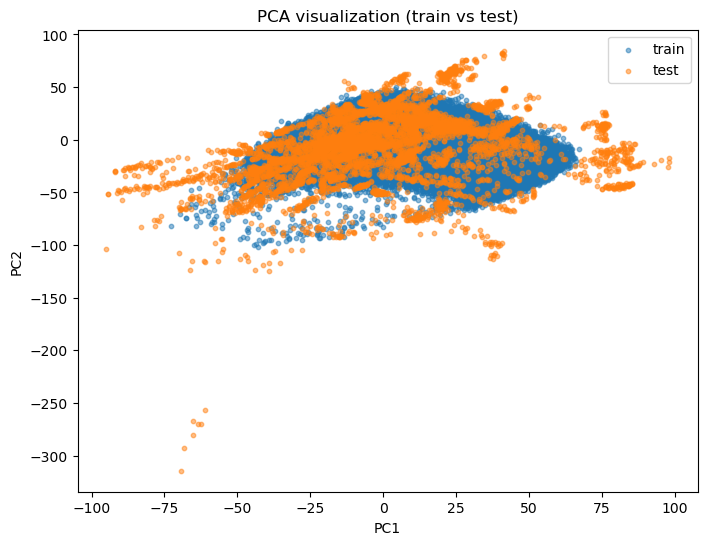

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 取出 PCA features
X_train_pca512 = adata_subset.obsm["X_pca"]
X_test_pca512  = adata.obsm["X_pca"]

# 合併
X_all = np.vstack([X_train_pca512, X_test_pca512])

# 建立來源標籤
labels_source = (
    ["train"] * X_train_pca512.shape[0] +
    ["test"]  * X_test_pca512.shape[0]
)

labels_source = np.array(labels_source)

# 再做 PCA -> 2D 用於視覺化
pca_2d = PCA(n_components=2, random_state=42)

X_2d = pca_2d.fit_transform(X_all)

# 轉 dataframe
df_plot = pd.DataFrame({
    "PC1": X_2d[:,0],
    "PC2": X_2d[:,1],
    "dataset": labels_source
})

# 畫圖
plt.figure(figsize=(8,6))

for label in df_plot["dataset"].unique():

    subset = df_plot[df_plot["dataset"] == label]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        label=label,
        alpha=0.5,
        s=10
    )

plt.xlabel("PC1")
plt.ylabel("PC2")

plt.title("PCA visualization (train vs test)")

plt.legend()

plt.show()